## Satellite Simulation Notebook
- Author Brandon Engelbrecht

In [73]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
from satellite_RFI.src.satellite_sims import satellite_sim as ss
import time
import pickle
import astropy.units as u
from datetime import datetime
import tqdm
import os


import scipy as sp
import numpy as np
import pandas as pd
import scipy.optimize as opt
import matplotlib.pyplot as plt

In [75]:
obs_time_input=None#'2021 9 30 20 06 36'
# fname = '1554156377'
fname = '1551055211'


"""
Establishing the file name
"""
if obs_time_input!=None:
    obs_time_in=[int(x) for x in obs_time_input.split()]
    obs_time = datetime(obs_time_in[0], obs_time_in[1], obs_time_in[2], obs_time_in[3], obs_time_in[4], obs_time_in[5])
    dt = obs_time.strftime('%Y-%m-%d %H:%M:%S')
    fname = int((obs_time - datetime(1970, 1, 1)).total_seconds())
    print ("File name to be used is: "+str(fname))

else:
    print ("File name to be used is: "+str(fname))
    dt = (datetime.utcfromtimestamp(float(fname)).strftime('%Y-%m-%d %H:%M:%S'))
    print ("Date of observation date: "+str(dt))



File name to be used is: 1551055211
Date of observation date: 2019-02-25 00:40:11


In [76]:
katdal_info = pickle.load(open('../../../Observation_results/Untangle/'+str(fname)+'/'+str(fname)+'_katdal_info.p', 'rb'), encoding='latin1')



info = [katdal_info[i] for i in katdal_info.keys()]

nd_s0=katdal_info['nd_s0']
nd_s0_coords=katdal_info['nd_s0_coords']
frequency=katdal_info['frequency']
fs=1000
fe=1500

data_save='../../../Observation_results/Untangle/'+str(fname)+'/sat_sims/'
if os.path.exists(data_save)==False:
    os.mkdir(data_save)
    
data_mkat = '../../../Observation_results/Untangle/'+str(fname)+'/'

### ----------------------------------------------------------------------------------
Initializing

In [77]:

s_time = time.time()


sat_sims = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc='../../../Observation_results/Untangle/'+str(fname)+'/',
            survey_info=[nd_s0, nd_s0_coords, frequency], sat_info='Satellite_Catalogue/table3B_satellite_v3.csv',
            plots_loc='../../../Observation_results/Untangle/Plots/'+str(fname)+'/',
            sat_beam='emss_beam_r', frequency_range=[fs,fe])

print (time.time() - s_time)


4.584829807281494


### --------------------------------------------------------------------------------------
Excecuting 

In [7]:
dic = {'Alpha':np.ones(71)*1}   # Parameter of ones based on the length of the satellite signals

In [79]:

s_time = time.time()


sat_sims.excecute(dic['Alpha'], obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=[1,0,0,0,0,0,0], add_sub=[1, 1], band_lvl=[None, None])


print (time.time() - s_time)
# 1.5, 0.6, 0.6, 2, 1.2, 0.6, 0

1.462956428527832


### ---------------------------------------------------------------------------
Multiple runnings

In [80]:
# choice_bias = [1.5, 0.6, 0.6, 2, 1.2, 0.6, 0]

# sigma = np.arange(1,6, 1)
# bw = 25
# sims = []
# for i in tqdm.tqdm(sigma):
#     emss_b.excecute(obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
#                 file_bias_choice=choice_bias,  # 2000-2100sec                
#                 add_sub=[1, 1], band_lvl=[bw, i])
#     sims.append(emss_b.simulation_slice)
    
# sims = np.array(sims)



# x_vals = sat_sims.frequency_band[sat_sims.frequency_idx[0]:sat_sims.frequency_idx[1]]
# observation = sat_sims._asat_simsverage_over_frequency_(sat_sims.calibration_data_slice)
# simulation = sat_sims.simulation_slice

In [81]:
# plt.figure(figsize=(10,4))

# textstr = '\n'.join([(sat+': '+str(choice_bias[i])) for i, sat in enumerate(sat_sims.satellite_type)])

# plt.plot(x_vals, observation, label=r'OBS')
# for i, sig in enumerate(sigma):
#     plt.plot(x_vals, sims[i], label=r'SIM: $\sigma-$'+str(sig)+', BW:'+str(bw)+'MHz')

# plt.text(1100, 50, textstr)
    
# plt.title('Variation in $\sigma$ values for OOB: Time-['+str(np.round(sat_sims.nd_s0[sat_sims.time_idx[0]], 2))
#           +'-'+str(np.round(sat_sims.nd_s0[sat_sims.time_idx[1]], 2))+'] seconds')



# plt.xlabel('Frequency [MHz]')
# plt.ylabel('Temperature [K] ')
# plt.legend()

# plt.tight_layout()
# plt.savefig('../../../Plots/'+fname+'_variation_in_sigma_'+str(np.round(sat_sims.nd_s0[sat_sims.time_idx[0]], 2))
#           +'-'+str(np.round(sat_sims.nd_s0[sat_sims.time_idx[1]], 2))+'_.png')

# plt.show()

### ------------------------------------------------------------------------------------------
Plotting

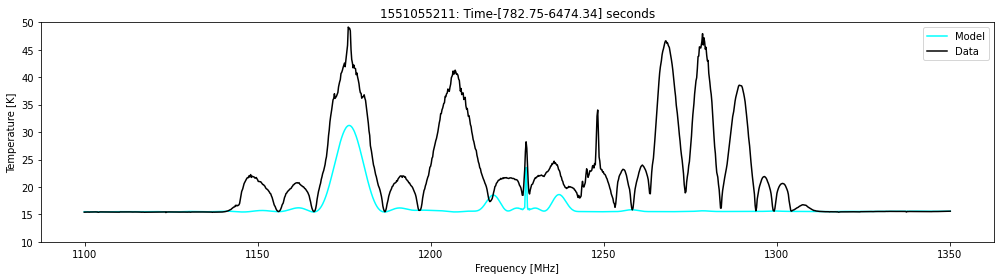

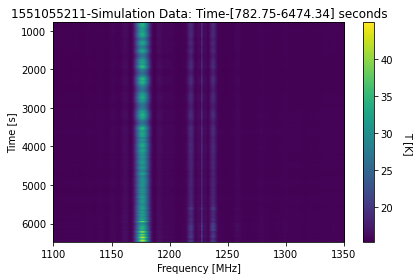

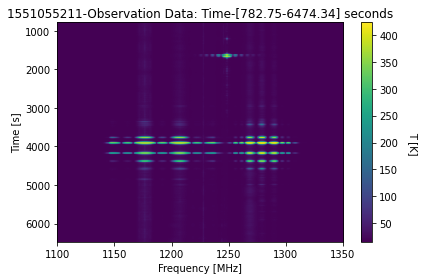

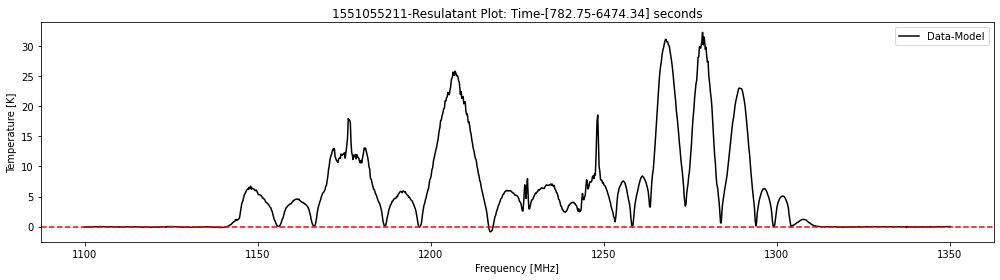

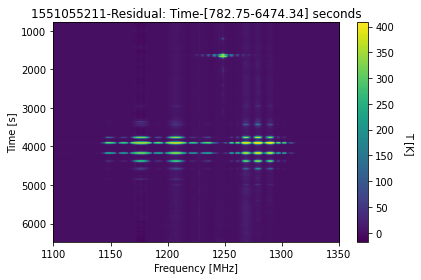

In [82]:
sat_sims.plotting(individual=None, logger=1, axis_limit=[None, None, 10, 50], tod_limit=None, save_file=None, file_type='pdf')


.

Extent values for the imshow plots

In [23]:
extent = [sat_sims.frequency_band[sat_sims.frequency_idx[0]], sat_sims.frequency_band[sat_sims.frequency_idx[1]],\
                    sat_sims.nd_s0[sat_sims.time_idx[1]], sat_sims.nd_s0[sat_sims.time_idx[0]]]

Extracting cosntellation sed

$P_{sat} = \dfrac{10^{[P_t]_i \times [G_t]_i / 10}}{4 \pi}$

Multiply a $\alpha_i$ term to the $[P_t]_i \times [G_t]_i$

.

### Setting up chi_square

Attempt 1: using the formulalism below $\\$
This $\chi^2$ is for the general amplitude multipied per constellation

$\chi^{2}$ = $\Sigma \dfrac{(O_i - E_i)^2}{E_i^2}$

In [84]:
# chi2_var = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc='../../../Observation_results/Untangle/'+str(fname)+'/',
#             survey_info=[nd_s0, nd_s0_coords, frequency], plots_loc='../../../Observation_results/Untangle/Plots/'+str(fname)+'/',
#             sat_beam='emss_beam_r', frequency_range=[fs,fe])


In [ ]:
chi2_var.excecute(dic['Alpha'], obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=[1.5, 0.6, 0.6, 2, 1.2, 0.6, 0],  # 2000-2100sec                
            sat_info='Satellite_Catalogue/table3B_satellite_v3.csv', add_sub=[1, 1], band_lvl=[None, None])

In [ ]:
# Setting the data for the calibration slice
data = chi2_var.calibration_data_slice

# Calculating the simulation values
simulation  = chi2_var.get_simulation_slice(file_bias_choice=[0.3, 0.6, 0.6, 0.5, 0.4, 0.3, 0])[1]


$\chi^2$ function for the general amplitude, remember we are using 6 variables instead of 7 because QZS is not operating in this area

In [ ]:
def chisq_func(constellations):
    """
    Chi2 function which will take in all the parameters for the satellites
    """

    simulation = chi2_var.get_simulation_slice(file_bias_choice=constellations)[1]
    data = chi2_var.calibration_data_slice
    
    chi_sq = np.sum((np.log10(simulation) - np.log10(data))**2 / np.log10(data)**2)
    return chi_sq

In [ ]:
# Initial value for the chi2
choice = np.array([1.5, 0.6, 0.6, 2., 1.2, 0.6, 0])


In [ ]:
# Testing the speed of the chi2

s_time = time.time()
chi2 = chisq_func(choice)
print (time.time() - s_time)

### Using scipy.optimize.minimize

In [ ]:
import scipy.optimize as opt

In [ ]:
cons_NM = opt.minimize(fun=chisq_func, 
                      x0=np.array([1.5, 0.6, 0.6, 2, 1.2, 0.6, 0]), 
                      method='Nelder-Mead',
                      bounds=((0.01,2),(0.01,2),(0.1,2),(0.01,2),(0.01,2),(0.01,2),(0.0,2)),
                      tol=None,
                      options={'maxiter':1e6,
                              'xatol':1e-5,
                              'fatol':1e-5})

In [ ]:
cons_PL = opt.minimize(fun=chisq_func, 
                      x0=np.array([1.5, 0.6, 0.6, 2, 1.2, 0.6, 0]), 
                      method='Powell',
                      bounds=((0.01,2),(0.01,2),(0.1,2),(0.01,2),(0.01,2),(0.01,2),(0.0,2)),
                      tol=100,
                      options={'maxiter':1e6,
                              'xtol':0.0001,
                              'ftol':0.0001})

In [ ]:
cons_TNC = opt.minimize(fun=chisq_func, 
                      x0=np.array([1.5, 0.6, 0.6, 2, 1.2, 0.6, 0]), 
                      method='TNC',
                      bounds=((0.01,2),(0.01,2),(0.1,2),(0.01,2),(0.01,2),(0.01,2),(0.0,2)),
                      tol=100,
                      options={'xtol':1,
                              'ftol':1,
                              'gtol':1})

In [ ]:
print (cons_NM.x)
print ('\n')
print (cons_PL.x)
print ('\n')
print (cons_TNC.x)

In [ ]:
chi2_test = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc='../../../Observation_results/Untangle/'+str(fname)+'/',
            survey_info=[nd_s0, nd_s0_coords, frequency], plots_loc='../../../Observation_results/Untangle/Plots/'+str(fname)+'/',
            sat_beam='emss_beam_r', frequency_range=[fs,fe])



In [ ]:
chi2_test.excecute(dic['Alpha'], obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=cons_TNC.x,  # 2000-2100sec                
            sat_info='Satellite_Catalogue/table3B_satellite_v3.csv', add_sub=[1, 1], band_lvl=[25, None])

In [ ]:
chi2_test.plotting(individual=None, logger=None, axis_limit=[None, None, 10, 50], tod_limit=None, save_file=None, file_type='pdf')


### ---------------------------------------------------------------------------------------------------

## Looking to use the $\chi^2$ on the follow 71 parameters

In [58]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
sat2 = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc='../../../Observation_results/Untangle/'+str(fname)+'/',
            survey_info=[nd_s0, nd_s0_coords, frequency], sat_info='Satellite_Catalogue/table3B_satellite_v3-1.csv',
            plots_loc='../../../Observation_results/Untangle/Plots/'+str(fname)+'/',
            sat_beam='emss_beam_r', frequency_range=[fs,fe])



In [62]:
# dic = {'Alpha':np.random.random(71)}    # Feeding a dictionary of random entries between 0 and 1
dic = {'Alpha':np.ones(13)} 

In [63]:
sat2.excecute(a_param=dic['Alpha'], obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=[1.5, 0.6, 0.6, 2, 1.2, 0.6, 0], add_sub=[1, 1], band_lvl=[None, None])




In [64]:
def chisq_func2(a_param):
    """
    Chi2 function which will take in all the parameters for the satellites
    """

    sat2.excecute(a_param, obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=[1.5, 0.6, 0.6, 2, 1.2, 0.6, 0], add_sub=[1, 1], band_lvl=[None, None])

    
    
    simulation = sat2.simulation_TOD_slice
    data = sat2.calibration_data_slice
    
    chi_sq = np.sum(((simulation) - (data))**2 / (data)**2)
    print (chi_sq)
    print (a_param)
    print ('\n')
    return chi_sq

In [65]:
chi2_res = chisq_func2(a_param=dic['Alpha'])

339657.96795687935
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]




13

In [66]:
np.sqrt((chi2_res)/(1199*2201))

0.35875774924934756

In [69]:
x = (0.1, 2)
# bnds = [x for i in range(len(dic['Alpha']))]
bnds = [x for i in range(len(dic['Alpha']))]

In [71]:
# bnds

In [72]:
# signal_TNC = opt.minimize(fun=chisq_func2, 
#                       x0=dic['Alpha'], 
#                       method='TNC')

signal_PL = opt.minimize(fun=chisq_func2, 
                         x0=np.random.random(len(dic['Alpha'])), 
                         method='Powell',
                         bounds=bnds, 
                         tol=1e-6, 
                         options={'maxiter':20})

<ipython-input-72-46e20fe2595a>:5: OptimizeWarning: Initial guess is not within the specified bounds
  signal_PL = opt.minimize(fun=chisq_func2,


326751.3838201605
[0.51706488 0.98077425 0.59082305 0.62903001 0.28225115 0.69890245
 0.30417502 0.33549473 0.06924209 0.09780873 0.22117075 0.67245574
 0.27202183]


326751.3618102581
[0.82573542 0.98077425 0.59082305 0.62903001 0.28225115 0.69890245
 0.30417502 0.33549473 0.06924209 0.09780873 0.22117075 0.67245574
 0.27202183]


326751.3299192377
[1.27426458 0.98077425 0.59082305 0.62903001 0.28225115 0.69890245
 0.30417502 0.33549473 0.06924209 0.09780873 0.22117075 0.67245574
 0.27202183]


326751.31026374275
[1.55147084 0.98077425 0.59082305 0.62903001 0.28225115 0.69890245
 0.30417502 0.33549473 0.06924209 0.09780873 0.22117075 0.67245574
 0.27202183]


326751.2981366965
[1.72279374 0.98077425 0.59082305 0.62903001 0.28225115 0.69890245
 0.30417502 0.33549473 0.06924209 0.09780873 0.22117075 0.67245574
 0.27202183]


326751.2906496832
[1.82867711 0.98077425 0.59082305 0.62903001 0.28225115 0.69890245
 0.30417502 0.33549473 0.06924209 0.09780873 0.22117075 0.67245574
 0.27202183]

In [53]:
np.sqrt((signal_PL.fun)/(1199*2201))

0.3507347151477924

In [54]:
signal_PL.fun

324636.04082662996

In [55]:
sat_test3 = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc='../../../Observation_results/Untangle/'+str(fname)+'/',
            survey_info=[nd_s0, nd_s0_coords, frequency], sat_info='Satellite_Catalogue/table3B_satellite_v3-1.csv',
            plots_loc='../../../Observation_results/Untangle/Plots/'+str(fname)+'/',
            sat_beam='emss_beam_r', frequency_range=[fs,fe])

In [56]:
sat_test3.excecute(signal_PL.x, obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=[1.5, 0.6, 0.6, 2, 1.2, 0.6, 0], add_sub=[1, 1], band_lvl=[None, None])



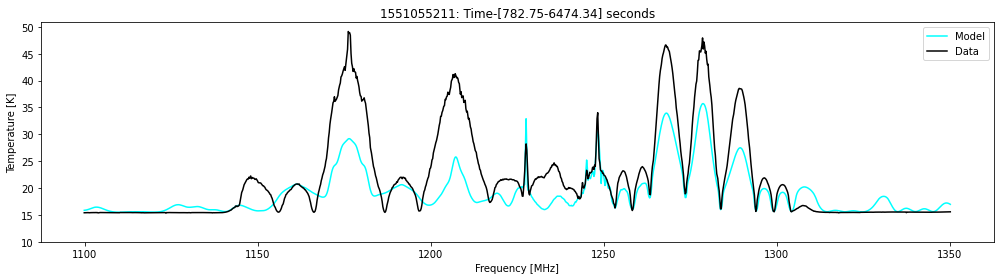

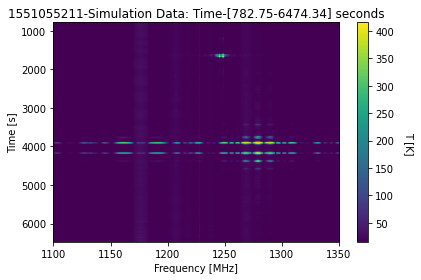

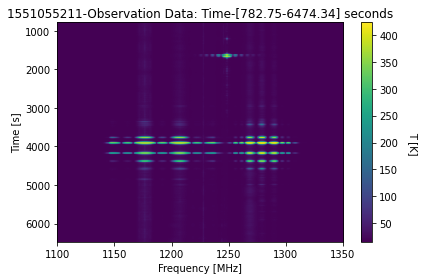

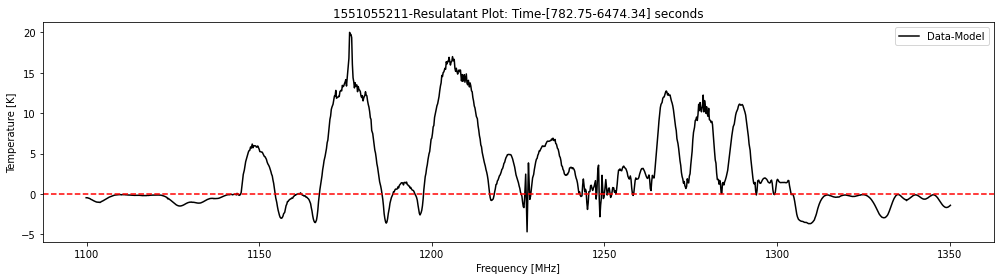

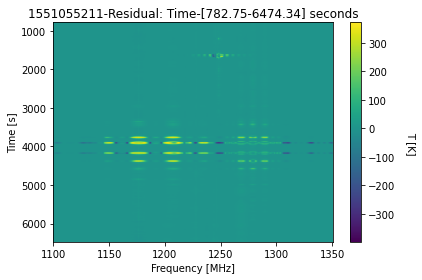

In [57]:
sat_test3.plotting(individual=None, logger=1, axis_limit=[None, None, 10, None], tod_limit=None, save_file=None, file_type='png')


In [ ]:
sat_test3_res = sat_test3.simulation_TOD_slice - sat_test3.calibration_data_slice

In [ ]:
plt.figure(figsize=(10,4))
plt.title('Observation - Simulation')
hb = plt.imshow(sat_test3_res.T, aspect='auto', extent=extent, vmin=None, vmax=None)

plt.ylabel('Time [s]')
plt.xlabel('Frequency [MHz]')

cbar = plt.colorbar(hb)
cbar.set_label(r'T [K]', rotation=270, labelpad=20, y=0.45)
plt.tight_layout()
# plt.savefig('../../../Observation_results/Untangle/Plots/1551055211/1551055211_big_chi.png')